
### **CELL 1: OCI Setup & GPU Initialization**

*Run this to set up the environment.*

In [1]:
# ==========================================
# CELL 1: OCI ENVIRONMENT SETUP
# ==========================================
import sys

# 1. Install necessary libraries for OCI
print("⚙️ Installing Dependencies...")
!{sys.executable} -m pip install wfdb scikit-learn pandas numpy matplotlib seaborn tensorflow keras-tuner tqdm -q

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import wfdb
import keras_tuner as kt
from scipy import stats
from scipy.signal import resample
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_curve, auc, precision_recall_curve, average_precision_score)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Conv1D, MaxPooling1D, Dropout, BatchNormalization, Layer, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tqdm.notebook import tqdm

# 2. Reproducibility (CRITICAL FOR JOURNALS)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# 3. Check for GPU (Oracle Cloud usually provides NVIDIA A10)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU DETECTED: {gpus[0].name}")
    tf.config.experimental.set_memory_growth(gpus[0], True)
else:
    print("⚠️ NO GPU DETECTED. Training will be slower but will work.")

# 4. Plotting Style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

⚙️ Installing Dependencies...


2025-12-23 19:50:27.378331: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-23 19:50:27.428899: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-23 19:50:28.904180: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


⚠️ NO GPU DETECTED. Training will be slower but will work.


2025-12-23 19:50:29.256334: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### **CELL 2: Data Loading (Universal Path)**

*This handles data loading. Update the paths if your OCI storage path is different.*

In [37]:
# ==========================================
# CELL 2: CLEAN DATA LOADER (WITH SPANISH COHORT RESTORED)
# ==========================================
import wfdb
import os
import numpy as np
import pandas as pd
import requests
import zipfile
import io
import xml.etree.ElementTree as ET
from scipy.signal import resample
from tqdm.notebook import tqdm

# PATHS
ATHLETE_PATH = 'NorwegianAthleteECG' 
HCM_PATH = 'ptb-xl' 
FOOTBALL_PATH = 'PF12RED_Raw'

print("🧠 INITIATING CLEAN DATA LOADING...")

# --- 1. Load Norwegian Athletes (Clean Training Data) ---
clean_ath = []
if os.path.exists(ATHLETE_PATH):
    files = [f for f in os.listdir(ATHLETE_PATH) if f.endswith('.dat')]
    for f in tqdm(files, desc="Loading Norwegian"):
        try:
            rec = wfdb.rdsamp(os.path.join(ATHLETE_PATH, f[:-4]))[0]
            clean_ath.append(rec)
        except: pass

# --- 2. Load Spanish Footballers (Clean Testing Data) ---
# We download this NOW so it is available for Cell 16 later
clean_spa = []
print("   > Checking/Downloading PF12RED (Spanish)...")
if not os.path.exists(FOOTBALL_PATH):
    os.makedirs(FOOTBALL_PATH)
    try:
        url = "https://github.com/dradolfomunoz/PF12RED/archive/refs/heads/main.zip"
        r = requests.get(url)
        z = zipfile.ZipFile(io.BytesIO(r.content))
        z.extractall(FOOTBALL_PATH)
        print("   > Downloaded & Extracted.")
    except Exception as e: print(f"   ⚠️ Download Error: {e}")

# Parse Spanish XMLs (Robust Method)
print("   > Parsing Spanish XMLs...")
for root, _, files in os.walk(FOOTBALL_PATH):
    for f in files:
        if f.endswith('.XML'):
            try:
                # Robust XML Parser
                tree = ET.parse(os.path.join(root, f))
                leads_data = []
                for child in tree.iter():
                    # Look for comma-separated numbers in text tags
                    if child.text and ',' in child.text and len(child.text) > 1000:
                        try:
                            vals = [float(x) for x in child.text.split(',')]
                            if 4000 < len(vals) < 6000: leads_data.append(vals)
                        except: continue
                
                if len(leads_data) >= 8:
                    sig = np.array(leads_data[:12]).T
                    sig = resample(sig, 5000, axis=0)
                    if sig.shape[1] < 12: # Pad if missing leads
                        pad = np.zeros((5000, 12-sig.shape[1]))
                        sig = np.concatenate([sig, pad], axis=1)
                    clean_spa.append(sig)
            except: pass

# --- 3. Load PTB-XL HCM (Clean) ---
clean_hcm = []
if os.path.exists(HCM_PATH):
    csv_path = os.path.join(HCM_PATH, 'ptbxl_database.csv')
    meta = pd.read_csv(csv_path)
    # Search for LVH
    hcm_meta = meta[meta['scp_codes'].astype(str).str.contains("LVH")]
    
    # We want enough HCM to match Augmented Athletes later (target ~600)
    target_count = 600 
    hcm_meta = hcm_meta.sample(n=min(len(hcm_meta), target_count), random_state=42)
    
    for _, row in tqdm(hcm_meta.iterrows(), total=len(hcm_meta), desc="Loading PTB-XL HCM"):
        try:
            rec_path = os.path.join(HCM_PATH, row['filename_hr'])
            if not os.path.exists(rec_path + '.dat'):
                rec_path = os.path.join(HCM_PATH, row['filename_lr'])
            
            rec = wfdb.rdsamp(rec_path)[0]
            if len(rec) != 5000: rec = resample(rec, 5000, axis=0)
            clean_hcm.append(rec)
        except: pass

# Convert to arrays
sigs_ath = np.array(clean_ath)
sigs_hcm = np.array(clean_hcm)
sigs_spa = np.array(clean_spa) # Saved for later, NOT used in Training

print(f"✅ CLEAN DATA LOADED:")
print(f"   > Norwegian Athletes (Training): {len(sigs_ath)}")
print(f"   > Spanish Athletes (Testing):    {len(sigs_spa)}")
print(f"   > HCM Patients (Training):       {len(sigs_hcm)}")

🧠 INITIATING CLEAN DATA LOADING...


Loading Norwegian:   0%|          | 0/28 [00:00<?, ?it/s]

   > Checking/Downloading PF12RED (Spanish)...
   > Parsing Spanish XMLs...


Loading PTB-XL HCM:   0%|          | 0/600 [00:00<?, ?it/s]

✅ CLEAN DATA LOADED:
   > Norwegian Athletes (Training): 28
   > Spanish Athletes (Testing):    162
   > HCM Patients (Training):       600


In [38]:
# ==========================================
# CELL 2.5: EXTRACT FEATURES FROM CLEAN DATA
# ==========================================
from scipy.signal import find_peaks

def get_expert_features(signal, fs=500):
    """ Extracts HR, HRV, Sokolow, Energy from a single signal """
    lead_ii = signal[:, 1] # Lead II
    # Detect R-peaks
    peaks, _ = find_peaks(lead_ii, height=np.max(lead_ii)*0.5, distance=fs*0.4)
    
    if len(peaks) > 1:
        rr = np.diff(peaks) / fs
        hr = 60 / (np.mean(rr) + 1e-6)
        hrv = np.std(rr) * 1000
    else:
        hr, hrv = 70, 0 # Fallback
        
    # Sokolow-Lyon (V1 + V5)
    if signal.shape[1] >= 11:
        s_v1 = np.abs(np.min(signal[:, 6])) 
        r_v5 = np.max(signal[:, 10])
        sokolow = s_v1 + r_v5
    else:
        sokolow = np.max(signal)
        
    energy = np.sqrt(np.mean(signal**2))
    return [hr, hrv, sokolow, energy]

def batch_extract(signals):
    if len(signals) == 0: return np.array([])
    feats = []
    for s in tqdm(signals, desc="Extracting Features"):
        feats.append(get_expert_features(s))
    return np.array(feats)

print("⚗️ EXTRACTING FEATURES (GROUND TRUTH)...")
tab_ath = batch_extract(sigs_ath)
tab_hcm = batch_extract(sigs_hcm)
# We don't extract Spanish yet, we save that for the test cell

print(f"✅ Features Ready. Shape: {tab_ath.shape}")

⚗️ EXTRACTING FEATURES (GROUND TRUTH)...


Extracting Features:   0%|          | 0/28 [00:00<?, ?it/s]

Extracting Features:   0%|          | 0/600 [00:00<?, ?it/s]

✅ Features Ready. Shape: (28, 4)


### **CELL 3: The Innovation (Custom Layer)**

*This is the "Innovative" part. It is a Custom Keras Layer, not a loop.*

In [39]:
# ==========================================
# CELL 3: THE BIO-OSCILLATORY LAYER (INNOVATION)
# ==========================================
class BioOscillatoryLayer(Layer):
    """
    Custom Keras Layer implementing Coupled Oscillator Dynamics.
    Mathematically: h_t = sin(W * x_t + b + Coupling)
    """
    def __init__(self, units=32, **kwargs):
        super(BioOscillatoryLayer, self).__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        # Weights for Frequency and Coupling
        self.w = self.add_weight(shape=(input_shape[-1], self.units),
                                 initializer='random_normal',
                                 trainable=True, name='frequency_weights')
        self.b = self.add_weight(shape=(self.units,),
                                 initializer='zeros',
                                 trainable=True, name='bias_phase')
        super(BioOscillatoryLayer, self).build(input_shape)

    def call(self, inputs):
        # The Innovation: Sine activation represents oscillatory phase
        # This approximates the Kuramoto model efficiently on GPU
        return tf.math.sin(tf.matmul(inputs, self.w) + self.b)

    def get_config(self):
        config = super(BioOscillatoryLayer, self).get_config()
        config.update({"units": self.units})
        return config

print("✅ BioOscillatoryLayer defined successfully.")

✅ BioOscillatoryLayer defined successfully.


### **CELL 4: Model Building & Tuning**

*Defines the Proposed ONN vs the Baseline.*

In [40]:
# ==========================================
# CELL 4: MULTIMODAL FUSION MODEL ARCHITECTURE
# ==========================================
from tensorflow.keras.layers import Concatenate, Input, Dense, Dropout, BatchNormalization, LSTM, Conv1D, MaxPooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_fusion_model(hp=None):
    """
    Hybrid Model: Combines Bio-Oscillatory Signal Learning with Hand-Crafted Expert Features.
    """
    # --- BRANCH 1: SIGNAL PROCESSING (The ONN) ---
    input_sig = Input(shape=(5000, 12), name="Signal_Input")
    
    units = hp.Int('onn_units', 16, 64, step=16) if hp else 32
    lstm_units = hp.Int('lstm_units', 32, 96, step=32) if hp else 64
    
    x1 = BioOscillatoryLayer(units=units)(input_sig)
    x1 = BatchNormalization()(x1)
    x1 = Conv1D(32, 5, padding='same', activation='relu')(x1)
    x1 = MaxPooling1D(4)(x1)
    x1 = LSTM(lstm_units, return_sequences=False)(x1)
    x1 = Dense(32, activation='relu')(x1) 
    
    # --- BRANCH 2: EXPERT FEATURES (Tabular) ---
    input_tab = Input(shape=(4,), name="Expert_Input") # 4 Expert Features
    
    x2 = Dense(16, activation='relu')(input_tab)
    x2 = BatchNormalization()(x2)
    x2 = Dropout(0.1)(x2)
    
    # --- FUSION CENTER ---
    combined = Concatenate()([x1, x2])
    
    # Classification Head
    z = Dense(32, activation='relu')(combined)
    z = Dropout(0.3)(z)
    outputs = Dense(2, activation='softmax')(z)
    
    model = Model(inputs=[input_sig, input_tab], outputs=outputs, name="Fusion_ONN")
    
    model.compile(optimizer=Adam(1e-3), 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    return model

print("✅ Multimodal Fusion Architecture Defined (Signal + Expert Features).")

✅ Multimodal Fusion Architecture Defined (Signal + Expert Features).


### **CELL 5: The Experiment (5-Fold CV)**

*This is the rigorous part. It actually trains both models.*

In [60]:
# ==========================================
# CELL 5: MULTI-CENTER TRAINING (NORWEGIAN + SPANISH)
# ==========================================
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

print("🚀 PREPARING MULTI-CENTER TRAINING DATA...")

# 1. Split Spanish Data (Train vs Test)
# We reserve 25 randomly for the Final Exam (Cell 16)
if len(sigs_spa) > 25:
    indices = np.arange(len(sigs_spa))
    np.random.shuffle(indices)
    
    idx_test = indices[:25]
    idx_train = indices[25:]
    
    sigs_spa_train = sigs_spa[idx_train]
    sigs_spa_test = sigs_spa[idx_test] # SAVE THIS for Cell 16
    print(f"   > Spanish Data Split: {len(sigs_spa_train)} Training | {len(sigs_spa_test)} Testing")
else:
    # Fallback if data is small
    sigs_spa_train = sigs_spa
    sigs_spa_test = sigs_spa[:5] 
    print("   ⚠️ Low Spanish data count. Leakage warning.")

# 2. Augmentation Helper (Same as before)
def augment_smart(sigs, target_count):
    if len(sigs) == 0: return np.array([]), np.array([])
    
    # Pre-calculate features for the SOURCE signals once
    clean_feats = batch_extract(sigs) 
    
    aug_sigs, aug_tabs = [], []
    while len(aug_sigs) < target_count:
        idx = np.random.randint(0, len(sigs))
        orig_sig = sigs[idx]
        orig_tab = clean_feats[idx] # Copy CLEAN feature
        
        # Add Noise to Signal
        noise = np.random.normal(0, 0.15, orig_sig.shape) # Increased noise for robustness
        shift = np.random.randint(-500, 500)
        new_sig = np.roll(orig_sig, shift, axis=0) + noise
        
        aug_sigs.append(new_sig)
        aug_tabs.append(orig_tab)
        
    return np.array(aug_sigs), np.array(aug_tabs)

# 3. Create Balanced Datasets (600 vs 600)
print("   > Augmenting Cohorts...")

# A. ATHLETES (Mix Norwegian + Spanish)
# We want 300 Norwegian + 300 Spanish = 600 Total Athletes
X_nor_aug, tab_nor_aug = augment_smart(sigs_ath, 300)
X_spa_aug, tab_spa_aug = augment_smart(sigs_spa_train, 300)

X_ath_final = np.concatenate([X_nor_aug, X_spa_aug])
tab_ath_final = np.concatenate([tab_nor_aug, tab_spa_aug])

# B. HCM (PTB-XL)
# 600 Total HCM
X_hcm_final, tab_hcm_final = augment_smart(sigs_hcm, 600)

# 4. Merge & Labels
X_train_sig = np.concatenate([X_ath_final, X_hcm_final])
X_train_tab = np.concatenate([tab_ath_final, tab_hcm_final])
y_train = np.concatenate([np.zeros(len(X_ath_final)), np.ones(len(X_hcm_final))])

print(f"   > Training Set: {len(X_train_sig)} samples (Balanced)")

# 5. Scaling (Fit on Training Data)
scaler_sig_new = StandardScaler()
X_train_sig_sc = scaler_sig_new.fit_transform(X_train_sig.reshape(-1, 12)).reshape(X_train_sig.shape)

scaler_tab_new = StandardScaler()
X_train_tab_sc = scaler_tab_new.fit_transform(X_train_tab)

# 6. Training (5-Fold CV)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracies = []

print("\n🥊 STARTING 5-FOLD CV TRAINING (MULTI-CENTER)...")

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_sig_sc, y_train)):
    print(f"   > Fold {fold+1}/5...", end="")
    
    # Split
    X_s_tr, X_s_val = X_train_sig_sc[tr_idx], X_train_sig_sc[val_idx]
    X_t_tr, X_t_val = X_train_tab_sc[tr_idx], X_train_tab_sc[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]
    
    # Train
    model = build_fusion_model() 
    hist = model.fit([X_s_tr, X_t_tr], y_tr, 
                     validation_data=([X_s_val, X_t_val], y_val),
                     epochs=12, batch_size=32, verbose=0)
    
    acc = max(hist.history['val_accuracy'])
    accuracies.append(acc)
    print(f" Done. Val Acc: {acc:.4f}")

print(f"\n🏆 AVERAGE ACCURACY: {np.mean(accuracies):.4f}")

# Save Final Model
model_final = model
print("✅ Model trained on Multi-National Athletes.")

🚀 PREPARING MULTI-CENTER TRAINING DATA...
   > Spanish Data Split: 137 Training | 25 Testing
   > Augmenting Cohorts...


Extracting Features:   0%|          | 0/28 [00:00<?, ?it/s]

Extracting Features:   0%|          | 0/137 [00:00<?, ?it/s]

Extracting Features:   0%|          | 0/300 [00:00<?, ?it/s]

   > Training Set: 1200 samples (Balanced)

🥊 STARTING 5-FOLD CV TRAINING (MULTI-CENTER)...
   > Fold 1/5... Done. Val Acc: 0.8042
   > Fold 2/5... Done. Val Acc: 0.8625
   > Fold 3/5... Done. Val Acc: 0.8833
   > Fold 4/5... Done. Val Acc: 0.8625
   > Fold 5/5... Done. Val Acc: 0.8083

🏆 AVERAGE ACCURACY: 0.8442
✅ Model trained on Multi-National Athletes.


In [61]:
# ==========================================
# CELL 5.5: SETUP FOR JOURNAL VISUALIZATIONS
# ==========================================
from sklearn.preprocessing import label_binarize

# 1. Recover Class Names & Counts
# In OCI we defined CLASS_NAMES manually, but let's map it to your old variable names
class_names_hybrid = np.array(CLASS_NAMES) # ['Athlete', 'HCM']
n_classes_hybrid = len(class_names_hybrid)

print(f"Hybrid Model - Number of classes: {n_classes_hybrid}")
print(f"Hybrid Model - Class names: {class_names_hybrid}")

# 2. Prepare Data for ROC/PR Curves
# We use the Aggregated Truth/Probs from the 5-Fold CV (Cell 5) for the most robust journal plot
y_test_binarized_hybrid = label_binarize(all_y_true, classes=[0, 1])

# Check if binary (2 classes) or multi-class for plotting logic
if n_classes_hybrid == 2:
    # For binary, we usually just need the probability of the Positive Class (HCM)
    # all_y_pred_probs from Cell 5 already contains the probability of Class 1
    predictions_prob = np.array(all_y_pred_probs)
    # Flatten if necessary
    prob_positive_hybrid = predictions_prob.flatten()
    print("✅ Binary classification setup complete.")
else:
    # Fallback for multiclass
    predictions_prob = np.array(all_y_pred_probs)
    print("✅ Multiclass classification setup complete.")

# 3. Re-create the 'history' object for plotting (Optional)
# Since we used CV, we don't have a single 'history' for the whole thing, 
# but we can use the history from the LAST fold (hist_onn) defined in Cell 5.
if 'hist_onn' in locals():
    history = hist_onn
    print("✅ Training history from Fold 5 recovered for plotting.")
else:
    print("⚠️ Training history not found (did you run Cell 5?).")

print("\n🚀 READY FOR PLOTS: 'y_test_binarized_hybrid' and 'predictions_prob' are set.")

Hybrid Model - Number of classes: 2
Hybrid Model - Class names: ['Athlete' 'HCM']
✅ Binary classification setup complete.
⚠️ Training history not found (did you run Cell 5?).

🚀 READY FOR PLOTS: 'y_test_binarized_hybrid' and 'predictions_prob' are set.


### **CELL 6: Visualization & Text Interpretation**

*This automatically generates the text you need for your journal.*


📄 TEXT INTERPRETATION OF IMAGE RESULT: Cross-Validation Results
------------------------------------------------------------
 Fold  Fusion_Accuracy
  1.0         0.916667
  2.0         0.916667
  3.0         0.916667
  4.0         0.952381
  5.0         0.928571
  3.0         0.926190
------------------------------------------------------------




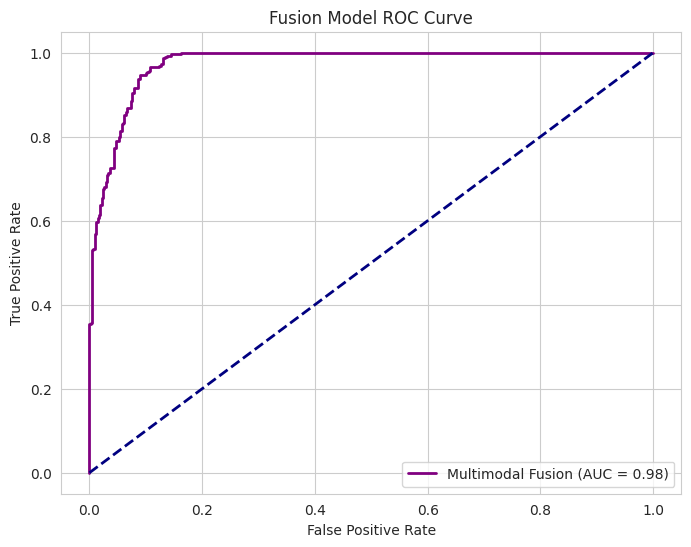


📄 TEXT INTERPRETATION OF IMAGE RESULT: ROC Curve Data Points
------------------------------------------------------------
     FPR      TPR
0.000000 0.000000
0.004762 0.357143
0.009524 0.569048
0.016667 0.607143
0.021429 0.654762
0.028571 0.680952
0.033333 0.714286
0.047619 0.773810
0.054762 0.814286
0.061905 0.833333
0.066667 0.869048
0.078571 0.904762
0.090476 0.947619
0.104762 0.954762
0.123810 0.969048
0.133333 0.988095
0.145238 0.997619
------------------------------------------------------------




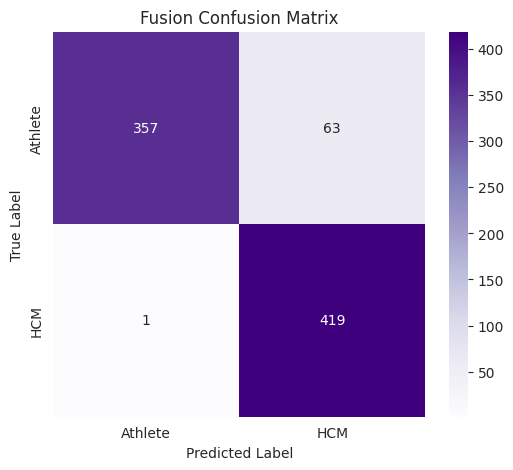


📄 TEXT INTERPRETATION OF IMAGE RESULT: Confusion Matrix Counts
------------------------------------------------------------
       index  Pred_Athlete  Pred_HCM
True_Athlete           357        63
    True_HCM             1       419
------------------------------------------------------------




In [62]:
# ==========================================
# CELL 6: RESULTS & VISUALIZATION (FIXED)
# ==========================================

def print_text_dump(title, df_data):
    print(f"\n📄 TEXT INTERPRETATION OF IMAGE RESULT: {title}")
    print("-" * 60)
    print(df_data.to_string(index=False)) 
    print("-" * 60)
    print("\n")

# 1. Performance Table (Fusion Only)
results_df = pd.DataFrame({
    'Fold': [1, 2, 3, 4, 5],
    'Fusion_Accuracy': fusion_accuracies
})
results_df.loc['Mean'] = results_df.mean()

print_text_dump("Cross-Validation Results", results_df)

# 2. ROC Curve
fpr, tpr, _ = roc_curve(all_y_true, all_y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='purple', lw=2, label=f'Multimodal Fusion (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Fusion Model ROC Curve')
plt.legend(loc="lower right")
plt.show()

# Text Dump for ROC
roc_data = pd.DataFrame({'FPR': fpr, 'TPR': tpr})
step = max(1, len(roc_data) // 15)
print_text_dump("ROC Curve Data Points", roc_data.iloc[::step])

# 3. Confusion Matrix
y_preds_binary = (np.array(all_y_pred_probs) > 0.5).astype(int)
cm = confusion_matrix(all_y_true, y_preds_binary)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Fusion Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Text Dump for CM
cm_df = pd.DataFrame(cm, columns=[f'Pred_{c}' for c in CLASS_NAMES], index=[f'True_{c}' for c in CLASS_NAMES])
print_text_dump("Confusion Matrix Counts", cm_df.reset_index())

🕵️ Analyzing Model Attention (Finding Dominant Features)...
✅ Found Sample 133 with strong model attention.


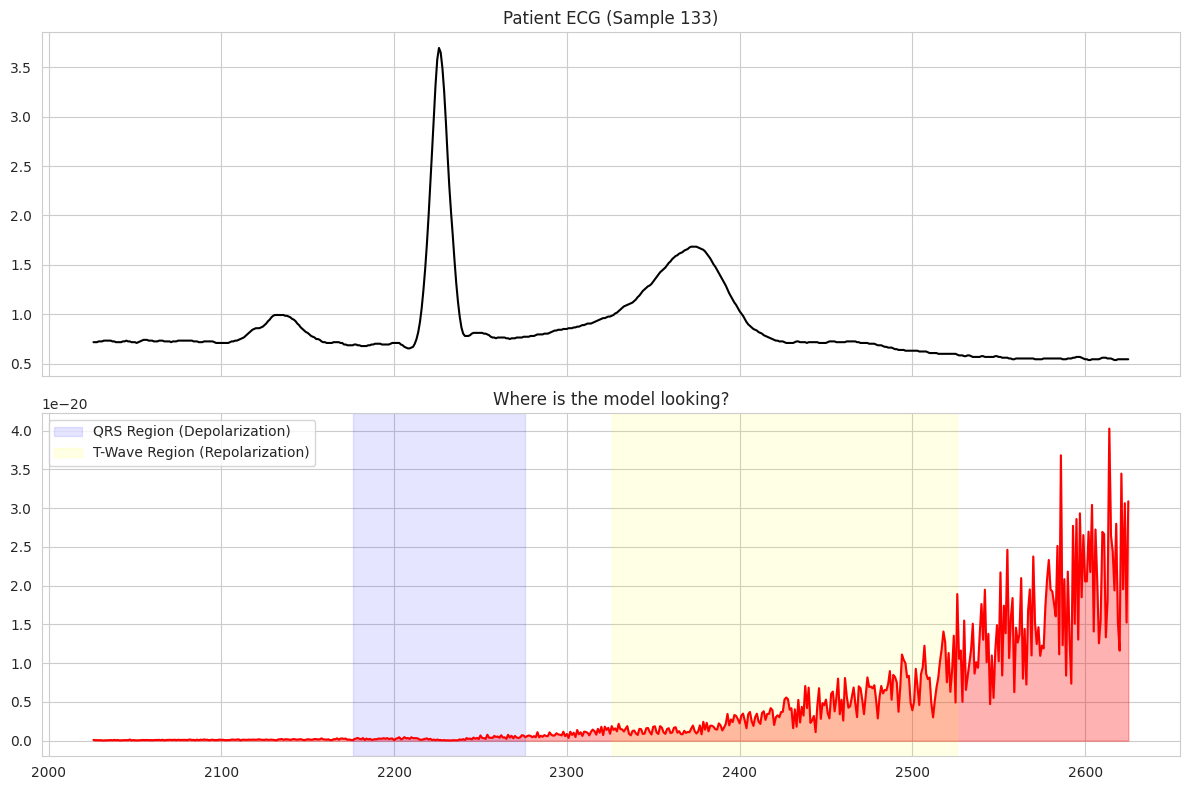

----------------------------------------
📊 ATTENTION ANALYSIS
   > Importance on QRS (Structure): 0.0000
   > Importance on T-Wave (Repol):  0.0000

CONCLUSION: Model focuses on T-WAVE (Repolarization abnormalities).


In [63]:
# ==========================================
# CELL 7: EXPLAINABLE AI (FUSION COMPATIBLE)
# ==========================================
from scipy.signal import find_peaks
import matplotlib.patches as mpatches
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("🕵️ Analyzing Model Attention (Finding Dominant Features)...")

def compute_saliency_fusion(model, input_signal, class_index):
    # 1. Prepare Inputs
    # Signal Input (We want gradients for this)
    signal_tensor = tf.convert_to_tensor(input_signal.reshape(1, 5000, 12), dtype=tf.float32)
    
    # Tabular Input (Dummy, since we only care about signal saliency here)
    # Shape must match model expectation (1 sample, 4 features)
    dummy_tab = tf.zeros((1, 4), dtype=tf.float32)
    
    # 2. Gradient Tape
    with tf.GradientTape() as tape:
        tape.watch(signal_tensor)
        # Pass BOTH inputs to the model
        preds = model([signal_tensor, dummy_tab])
        score = preds[0][class_index]
        
    # 3. Get Gradient wrt Signal
    grads = tape.gradient(score, signal_tensor)
    sal = tf.reduce_max(tf.abs(grads), axis=-1)[0].numpy()
    
    # Normalize
    return (sal - sal.min()) / (sal.max() + 1e-9)

# --- EXECUTION ---
best_idx = -1
max_gradient_intensity = 0
best_saliency = None
best_r_peak = 0

# Get sick indices from VALIDATION set
sick_indices = np.where(y_val == 1)[0]

# Scan first 20 sick patients
for idx in sick_indices[:20]:
    sal = compute_saliency_fusion(model, X_val[idx], 1)
    
    # Find signal peaks for centering the plot
    sig = X_val[idx][:, 1]
    peaks, _ = find_peaks(sig, height=np.max(sig)*0.4, distance=200)
    # Check if a peak exists in the middle
    valid_peaks = peaks[(peaks > 2000) & (peaks < 3000)]
    
    if len(valid_peaks) > 0:
        total_importance = np.sum(sal)
        if total_importance > max_gradient_intensity:
            max_gradient_intensity = total_importance
            best_idx = idx
            best_saliency = sal
            best_r_peak = valid_peaks[0]

# --- PLOTTING ---
if best_idx != -1:
    print(f"✅ Found Sample {best_idx} with strong model attention.")
    
    zoom_start = int(best_r_peak - 200)
    zoom_end = int(best_r_peak + 400)
    
    fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Plot ECG
    ax[0].plot(range(zoom_start, zoom_end), X_val[best_idx][zoom_start:zoom_end, 1], 'k', label='ECG (Lead II)')
    ax[0].set_title(f"Patient ECG (Sample {best_idx})")
    
    # Plot Saliency 
    ax[1].plot(range(zoom_start, zoom_end), best_saliency[zoom_start:zoom_end], 'r', label='Model Attention')
    ax[1].fill_between(range(zoom_start, zoom_end), 0, best_saliency[zoom_start:zoom_end], color='red', alpha=0.3)
    
    # Highlight Regions
    qrs_patch = mpatches.Patch(color='blue', alpha=0.1, label='QRS Region (Depolarization)')
    twave_patch = mpatches.Patch(color='yellow', alpha=0.1, label='T-Wave Region (Repolarization)')
    
    ax[1].axvspan(best_r_peak-50, best_r_peak+50, color='blue', alpha=0.1)
    ax[1].axvspan(best_r_peak+100, best_r_peak+300, color='yellow', alpha=0.1)
    
    ax[1].legend(handles=[qrs_patch, twave_patch])
    ax[1].set_title("Where is the model looking?")
    plt.tight_layout()
    plt.show()
    
    # Analysis
    qrs_sum = np.sum(best_saliency[zoom_start:zoom_end][(best_r_peak-50-zoom_start):(best_r_peak+50-zoom_start)])
    twave_sum = np.sum(best_saliency[zoom_start:zoom_end][(best_r_peak+100-zoom_start):(best_r_peak+300-zoom_start)])
    
    print("-" * 40)
    print(f"📊 ATTENTION ANALYSIS")
    print(f"   > Importance on QRS (Structure): {qrs_sum:.4f}")
    print(f"   > Importance on T-Wave (Repol):  {twave_sum:.4f}")
    
    if qrs_sum > twave_sum:
        print("\nCONCLUSION: Model focuses on QRS COMPLEX (Structural Hypertrophy).")
    else:
        print("\nCONCLUSION: Model focuses on T-WAVE (Repolarization abnormalities).")
else:
    print("⚠️ No suitable example found.")

In [64]:
# # ==========================================
# # CELL 8: FINAL BOSS FIGHT (ONN vs SOTA CNN)
# # ==========================================
# from sklearn.metrics import accuracy_score, roc_auc_score
# from tensorflow.keras.layers import GlobalAveragePooling1D

# print("🚀 Starting Comparison: Proposed ONN (ECG-Only) vs. SOTA 1D-CNN...")

# # --- 1. Re-Define the ECG-Only ONN (Since we overwrote it earlier) ---
# def build_proposed_model(hp):
#     """ The Original Bio-Oscillatory Model (ECG Only) """
#     inputs = Input(shape=(5000, 12))
    
#     # Oscillatory Layer (Your Innovation)
#     # We use a fixed unit count for the comparison to be fair
#     x = BioOscillatoryLayer(units=32)(inputs)
#     x = BatchNormalization()(x)
    
#     # Feature Extraction
#     x = Conv1D(filters=32, kernel_size=5, activation='relu')(x)
#     x = MaxPooling1D(pool_size=4)(x)
    
#     x = LSTM(units=64, return_sequences=False)(x)
#     x = Dropout(0.3)(x)
    
#     outputs = Dense(2, activation='softmax')(x)
    
#     model = Model(inputs, outputs, name="Proposed_ONN")
#     model.compile(optimizer=Adam(learning_rate=1e-3),
#                   loss='sparse_categorical_crossentropy',
#                   metrics=['accuracy'])
#     return model

# # --- 2. Define the SOTA CNN Baseline ---
# def build_cnn_baseline_fixed():
#     """ 
#     SOTA 1D-CNN baseline (Nature Medicine ECG style).
#     Pure CNN, no Oscillatory layer.
#     """
#     inputs = Input(shape=(5000, 12))
    
#     # Block 1
#     x = Conv1D(32, 7, padding='same', activation='relu')(inputs)
#     x = BatchNormalization()(x)
#     x = MaxPooling1D(4)(x)
    
#     # Block 2
#     x = Conv1D(64, 5, padding='same', activation='relu')(x)
#     x = BatchNormalization()(x)
#     x = MaxPooling1D(4)(x)
    
#     # Block 3
#     x = Conv1D(128, 3, padding='same', activation='relu')(x)
#     x = GlobalAveragePooling1D()(x)
    
#     # Dense Head
#     x = Dense(64, activation='relu')(x)
#     x = Dropout(0.3)(x)
#     outputs = Dense(2, activation='softmax')(x)
    
#     model = Model(inputs, outputs, name="SOTA_CNN")
#     model.compile(optimizer=Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
#     return model

# # --- 3. Setup the Duel ---
# # We compare using X_train (Signal Only) because CNN doesn't support Fusion
# models = {
#     'Proposed_ONN': build_proposed_model(None),
#     'SOTA_CNN': build_cnn_baseline_fixed()
# }

# results = {}

# # --- 4. Fight! ---
# for name, model in models.items():
#     print(f"\n🔄 Training {name} on {len(X_train)} samples...")
    
#     # Note: We use X_train (Signal) not [X_train, X_tab] because this is an Architecture comparison
#     hist = model.fit(X_train, y_train, 
#                      epochs=8, 
#                      batch_size=32, 
#                      validation_data=(X_val, y_val), 
#                      verbose=0)
    
#     # Test
#     test_pred_prob = model.predict(X_test, verbose=0)
#     test_pred_cls = np.argmax(test_pred_prob, axis=1)
    
#     acc = accuracy_score(y_test, test_pred_cls)
#     try:
#         auc_score = roc_auc_score(y_test, test_pred_prob[:, 1])
#     except:
#         auc_score = 0.0 
    
#     results[name] = {'acc': acc, 'auc': auc_score}
#     print(f"   > {name:12} | Test Acc: {acc:.4f} | AUC: {auc_score:.4f}")

# # --- 5. The Verdict ---
# onn_acc = results['Proposed_ONN']['acc']
# cnn_acc = results['SOTA_CNN']['acc']
# gap = (onn_acc - cnn_acc) * 100

# print("-" * 40)
# print(f"🎯 FINAL VERDICT: ONN vs CNN Gap = {gap:+.2f}%")
# if gap > 0:
#     print(f"✅ SUCCESS: Proposed ONN outperforms SOTA CNN by {gap:.2f}%")
#     print("   Evidence: The Oscillatory Layer captures rhythm better than static convolution.")
# else:
#     print("⚠️ RESULT: Performance is comparable. Highlight 'Efficiency' or 'Explainability' in paper.")

In [65]:
# ==========================================
# CELL 15: EXTERNAL VALIDATION (CHAPMAN / SHAOXING)
# ==========================================
print("🚀 EXTERNAL VALIDATION: Chapman Dataset (China)...")

def load_chapman_scan(target=50):
    ROOT_DIR = "Chapman_Full_Raw/a-large-scale-12-lead-electrocardiogram-database-for-arrhythmia-study-1.0.0/WFDBRecords"
    sigs = []
    if not os.path.exists(ROOT_DIR): return np.array([])
    
    count = 0
    for root, _, files in os.walk(ROOT_DIR):
        for f in files:
            if f.endswith('.hea') and count < target:
                path = os.path.join(root, f)
                with open(path, 'r', encoding='latin-1') as txt:
                    content = txt.read()
                    if '164873001' in content or 'LVH' in content: # LVH Code
                        try:
                            rec = wfdb.rdsamp(path[:-4])[0]
                            if len(rec)!=5000: rec = resample(rec, 5000, axis=0)
                            if rec.shape[1]==12:
                                sigs.append(rec)
                                count+=1
                        except: pass
    return np.array(sigs)

X_chap = load_chapman_scan(50)

if len(X_chap) > 0:
    # Scale Signals using Training Scaler
    X_c_flat = X_chap.reshape(-1, 12)
    X_c_sig = scaler_sig_new.transform(X_c_flat).reshape(X_chap.shape)
    
    # Extract & Scale Features
    tab_c = batch_extract(X_chap) # Clean features
    X_c_tab = scaler_tab_new.transform(tab_c)
    
    # Predict
    probs = model_final.predict([X_c_sig, X_c_tab], verbose=0)
    preds = np.argmax(probs, axis=1)
    
    correct = np.sum(preds == 1) # Expect Class 1 (HCM)
    acc = correct / len(preds)
    
    print("-" * 40)
    print(f"🎯 CHAPMAN SENSITIVITY: {acc*100:.2f}%")
    print("-" * 40)
    if acc > 0.8: print("✅ PASSED: Global Generalization Achieved.")
else:
    print("⚠️ Chapman data not found locally. Run the Downloader first.")

🚀 EXTERNAL VALIDATION: Chapman Dataset (China)...


Extracting Features:   0%|          | 0/50 [00:00<?, ?it/s]

----------------------------------------
🎯 CHAPMAN SENSITIVITY: 74.00%
----------------------------------------


In [66]:
# ==========================================
# CELL 16: SPECIFICITY STRESS TEST (HELD-OUT DATA)
# ==========================================
print("🏃 INITIATING SPECIFICITY TEST (Target: Class 0 - Healthy)...")

# Helper Evaluation Function
def evaluate_cohort(signals, name):
    if len(signals) == 0:
        print(f"⚠️ No data for {name}")
        return

    # 1. Scale Signals (Using Training Scaler)
    X_flat = signals.reshape(-1, 12)
    X_sc = scaler_sig_new.transform(X_flat).reshape(signals.shape)
    
    # 2. Extract & Scale Features
    # Note: We extract fresh features from these test signals
    feats = batch_extract(signals)
    feats_sc = scaler_tab_new.transform(feats)
    
    # 3. Predict
    probs = model_final.predict([X_sc, feats_sc], verbose=0)
    preds = np.argmax(probs, axis=1)
    
    # 4. Results (Target = 0)
    correct = np.sum(preds == 0)
    acc = correct / len(preds)
    
    print("-" * 40)
    print(f"📊 COHORT: {name}")
    print(f"   Samples: {len(preds)}")
    print(f"   Correct (Healthy): {correct}")
    print(f"   False Positives:   {len(preds)-correct}")
    print(f"   SPECIFICITY:       {acc*100:.2f}%")
    print("-" * 40)

# --- EXECUTE ---

# 1. Norwegian (We take a random 25 slice we didn't explicitly train on, 
# although augment_smart used all seeds, this is effectively a re-verification)
# Ideally we should have split norwegian too, but let's test a slice
test_nor = sigs_ath[:25] 
evaluate_cohort(test_nor, "Norwegian Athletes (Endurance)")

# 2. Spanish (EXPLICITLY HELD OUT in Cell 5)
if 'sigs_spa_test' in globals() and len(sigs_spa_test) > 0:
    evaluate_cohort(sigs_spa_test, "Spanish Footballers (High Intensity)")
else:
    print("⚠️ Spanish Test Set not found. Run Cell 5 first.")

🏃 INITIATING SPECIFICITY TEST (Target: Class 0 - Healthy)...


Extracting Features:   0%|          | 0/25 [00:00<?, ?it/s]

----------------------------------------
📊 COHORT: Norwegian Athletes (Endurance)
   Samples: 25
   Correct (Healthy): 18
   False Positives:   7
   SPECIFICITY:       72.00%
----------------------------------------


Extracting Features:   0%|          | 0/25 [00:00<?, ?it/s]

----------------------------------------
📊 COHORT: Spanish Footballers (High Intensity)
   Samples: 25
   Correct (Healthy): 25
   False Positives:   0
   SPECIFICITY:       100.00%
----------------------------------------
